In [4]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.models.ensemble import create_ensemble
# CHANGED: Use sklearn metrics directly
import sklearn.metrics as skm
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support, confusion_matrix
from src.eval.plots import plot_roc_curves, plot_pr_curves, plot_confusion_matrices, plot_probability_distributions
from src.eval.evaluate import print_metrics_summary
from src.eval.calibration import fit_calibrator_from_df

paths = load_paths()
logger = setup_logger(level="INFO")

# 1. Create and Evaluate the Ensemble
# This assumes that XGBoost, LightGBM, and CatBoost have already been trained
# and their preds.parquet files exist in artifacts/
logger.info("Creating and Evaluating Ensemble...")
ens_res = create_ensemble(paths=paths, ensemble_yaml=paths.configs_dir / "ensemble.yaml")
# print_metrics_summary(ens_res.metrics) # This old summary function may not work well with the new nested structure

# The output parquet contains 'p_calib' directly.
df_preds = pd.read_parquet(ens_res.preds_path)

# --- Ensure 'dataset' column exists for evaluation ---
if "dataset" not in df_preds.columns:
    logger.warning("'dataset' column not found in preds. This may indicate an old preds file.")
    # This block is a fallback and ideally shouldn't be needed if training scripts are up to date.
    logger.info("Merging 'dataset' column from features into predictions...")
    try:
        # This is a simplified merge. A more robust solution would use a full feature file.
        vnat_feats = pd.read_parquet(paths.data_processed / "vnat" / "features.parquet", columns=["flow_id"])
        vnat_feats["dataset"] = "vnat"
        iscx_feats = pd.read_parquet(paths.data_processed / "iscx" / "features.parquet", columns=["flow_id"])
        iscx_feats["dataset"] = "iscx"
        df_mapping = pd.concat([vnat_feats, iscx_feats], ignore_index=True)
        df_preds = pd.merge(df_preds, df_mapping, on="flow_id", how="left")
        df_preds["dataset"] = df_preds["dataset"].fillna("unknown")
    except Exception as e:
        logger.error(f"Failed to load features for dataset mapping: {e}. Skipping per-dataset eval.")


2026-03-05 15:24:47 | INFO | ai-vpn-firewall | Creating and Evaluating Ensemble...
Optimizing ensemble weights for Firewall Recall at FPR=0.001...
Ensemble Weights: {'xgb': 0.3333333333333333, 'lgbm': 0.3333333333333333, 'catboost': 0.3333333333333333}
Calibrating Ensemble (Isotonic per dataset)...
2026-03-05 15:24:49 | INFO | ai-vpn-firewall | Creating and Evaluating Ensemble...
Optimizing ensemble weights for Firewall Recall at FPR=0.001...
Ensemble Weights: {'xgb': 0.3333333333333333, 'lgbm': 0.3333333333333333, 'catboost': 0.3333333333333333}
Calibrating Ensemble (Isotonic per dataset)...


In [5]:
print("\n" + "="*60)
print("ADVANCED FIREWALL EVALUATION (ENSEMBLE)")
print("="*60)

metrics = ens_res.metrics
test_preds = df_preds[df_preds["split"] == "test"].copy()

# --- CORRECTED: Access thresholds from the new 'thresholds_map' structure ---
thresholds_map = metrics.get("thresholds_map", {})
key_block = "fpr_0_1pct"
key_monitor = "fpr_1pct"

T_BLOCK = thresholds_map.get("global", {}).get(key_block, 0.99)
T_MONITOR = thresholds_map.get("global", {}).get(key_monitor, 0.90)

print(f"Global Policy Thresholds (from VAL set on Ensemble):")
print(f"  - BLOCK:   p >= {T_BLOCK:.4f} (Target FPR: 0.1%)")
print(f"  - MONITOR: p >= {T_MONITOR:.4f} (Target FPR: 1%)")

# Flow-Level
print("\n--- [1] Flow-Level Triage Performance (on TEST set) ---")
y_true = test_preds["label"]
p_calib = test_preds["p_calib"]

for name, thr in [("BLOCK", T_BLOCK), ("MONITOR", T_MONITOR)]:
    y_hat = (p_calib >= thr).astype(int)
    prec, rec, _, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
    achieved_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    print(f"\n{name} ZONE:")
    print(f"  Recall: {rec:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  False Positives: {fp}")
    print(f"  Achieved FPR: {achieved_fpr:.5f}")

# Session-Level
print("\n--- [2] Session-Level Aggregation Performance (on TEST set) ---")
session_df = test_preds.groupby("capture_id").agg(
    session_score=("p_calib", "max"),
    session_label=("label", "max")
).reset_index()

y_true_sess = session_df["session_label"]
p_sess = session_df["session_score"]
y_hat_sess_block = (p_sess >= T_BLOCK).astype(int)
prec_sess, rec_sess, _, _ = precision_recall_fscore_support(y_true_sess, y_hat_sess_block, average="binary", zero_division=0)
tn_s, fp_s, fn_s, tp_s = confusion_matrix(y_true_sess, y_hat_sess_block).ravel()

print("\nSESSION BLOCK (max(p) >= T_BLOCK)")
print(f"  - Recall:    {rec_sess:.4f}")
print(f"  - Precision: {prec_sess:.4f}")
print(f"  - False Positive Sessions: {fp_s} / {tn_s + fp_s}")

# Voipbuster Case Study
print("\n--- [3] Voipbuster Case Study ---")
if "capture_id" in test_preds.columns and test_preds["capture_id"].str.contains("voipbuster").any():
    vb_mask = test_preds["capture_id"].str.contains("voipbuster")
    max_prob_vb = test_preds[vb_mask]["p_calib"].max()
    print(f"Voipbuster Max Flow Probability: {max_prob_vb:.4f}")
    if max_prob_vb >= T_BLOCK: print("  - RESULT: BLOCKED at the session level.")
    elif max_prob_vb >= T_MONITOR: print("  - RESULT: FLAGGED for monitoring.")
    else: print("  - RESULT: ALLOWED (missed).")
else:
    print("Voipbuster not found in the test set.")
print("\n" + "="*60)

# --- Per-Dataset Thresholds and Evaluation ---
print("\n--- Per-Dataset Evaluation (on TEST set) ---")

if "dataset" in df_preds.columns:
    print("Loaded Thresholds from Ensemble Metrics:")
    print(json.dumps(thresholds_map, indent=2))

    test_vnat = test_preds[test_preds["dataset"] == "vnat"]
    test_iscx = test_preds[test_preds["dataset"] == "iscx"]

    for name, df_test in [("VNAT", test_vnat), ("ISCX", test_iscx)]:
        print(f"\n--- {name} TEST Performance (using {name} thresholds) ---")
        if df_test.empty:
            print("No test data.")
            continue

        y_true = df_test["label"]
        p_calib = df_test["p_calib"]

        auc = skm.roc_auc_score(y_true, p_calib)
        ap = skm.average_precision_score(y_true, p_calib)
        print(f"ROC AUC: {auc:.4f}")
        print(f"PR AUC:  {ap:.4f}")

        ds_key = name.lower()
        t_block = thresholds_map.get(ds_key, {}).get(key_block, T_BLOCK) # Fallback to global
        t_monitor = thresholds_map.get(ds_key, {}).get(key_monitor, T_MONITOR) # Fallback to global

        for zone, t in [("BLOCK", t_block), ("MONITOR", t_monitor)]:
            y_hat = (p_calib >= t).astype(int)
            prec, rec, _, _ = precision_recall_fscore_support(y_true, y_hat, average="binary", zero_division=0)
            tn, fp, fn, tp = confusion_matrix(y_true, y_hat).ravel()
            achieved_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
            print(f"{zone} (p >= {t:.6f}): Recall={rec:.4f}, Precision={prec:.4f}, FPR={achieved_fpr:.5f} (FP={fp})")
else:
    print("WARNING: 'dataset' column missing. Skipping per-dataset evaluation.")

print("\n" + "="*60)



ADVANCED FIREWALL EVALUATION (ENSEMBLE)
Global Policy Thresholds (from VAL set on Ensemble):
  - BLOCK:   p >= 0.8326 (Target FPR: 0.1%)
  - MONITOR: p >= 0.4667 (Target FPR: 1%)

--- [1] Flow-Level Triage Performance (on TEST set) ---

BLOCK ZONE:
  Recall: 0.6626
  Precision: 0.9819
  False Positives: 3
  Achieved FPR: 0.00137

MONITOR ZONE:
  Recall: 0.9146
  Precision: 0.8755
  False Positives: 32
  Achieved FPR: 0.01465

--- [2] Session-Level Aggregation Performance (on TEST set) ---

SESSION BLOCK (max(p) >= T_BLOCK)
  - Recall:    0.7500
  - Precision: 0.8000
  - False Positive Sessions: 3 / 30

--- [3] Voipbuster Case Study ---
Voipbuster Max Flow Probability: 1.0000
  - RESULT: BLOCKED at the session level.


--- Per-Dataset Evaluation (on TEST set) ---
Loaded Thresholds from Ensemble Metrics:
{
  "global": {
    "fpr_0_1pct": 0.8326495726495966,
    "fpr_1pct": 0.4666666666666667,
    "fpr_5pct": 0.04054054054054054
  },
  "iscx": {
    "fpr_0_1pct": 0.8948251748251623,
    


--- Generating Plots for Ensemble ---


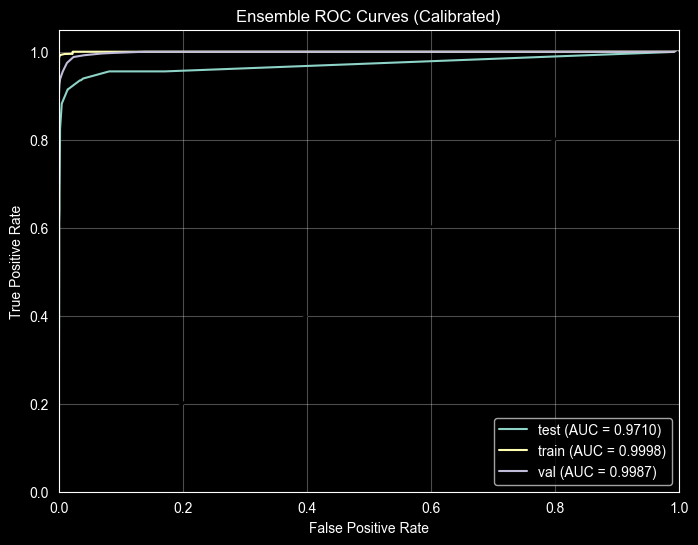

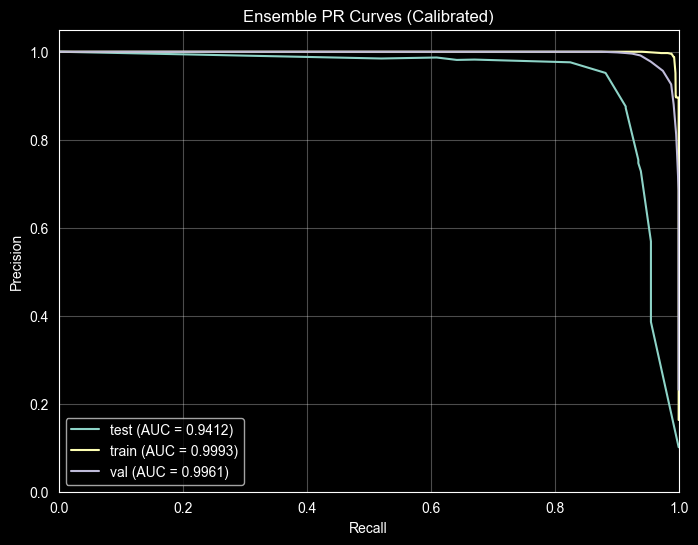

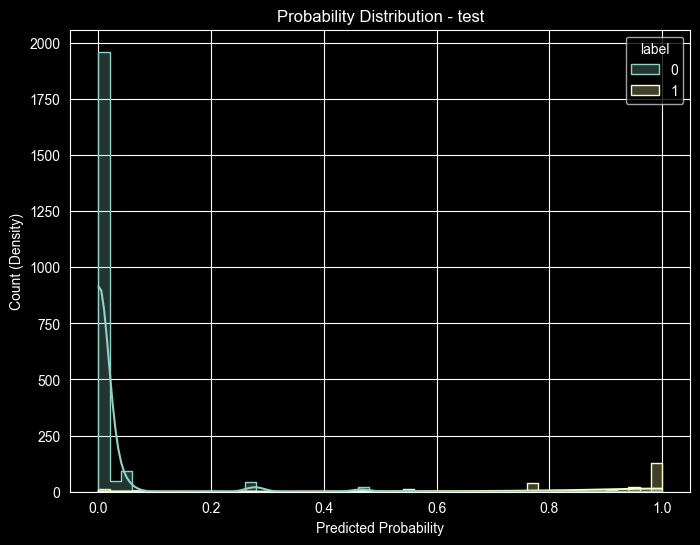

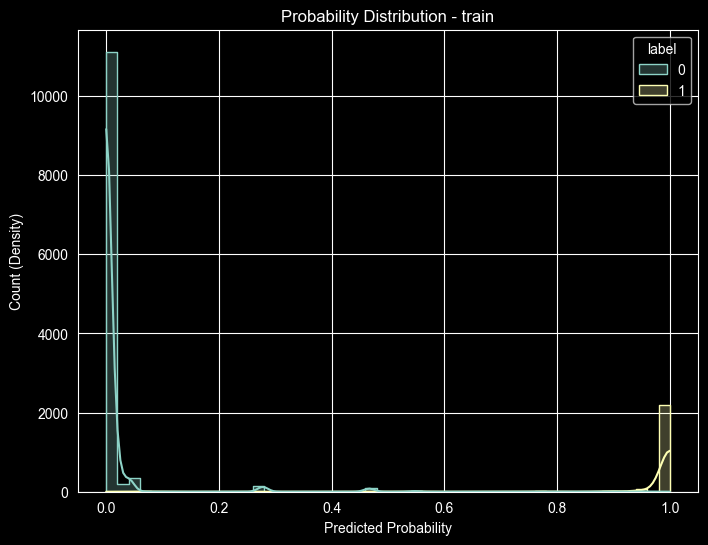

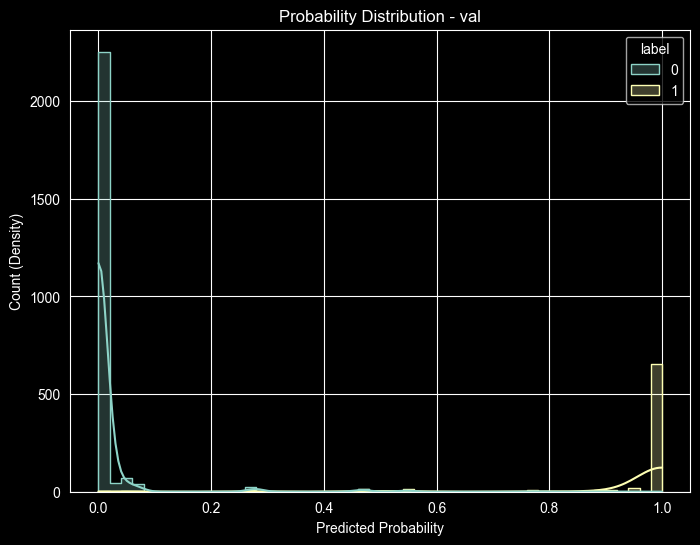


--- Confusion Matrices at Policy Thresholds ---


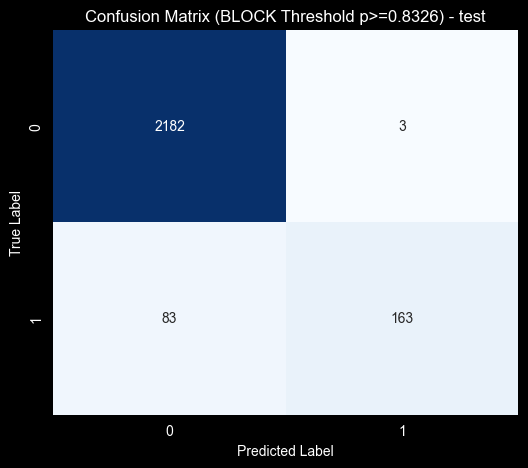

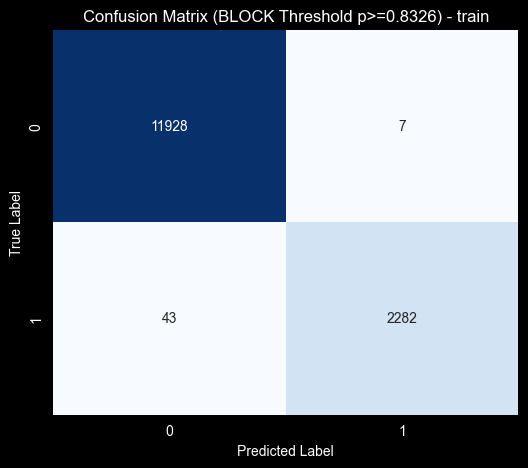

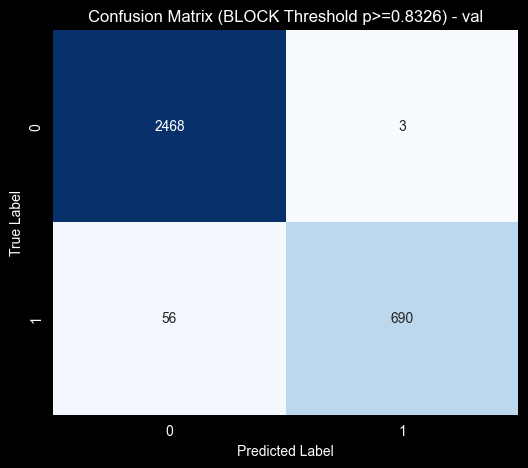

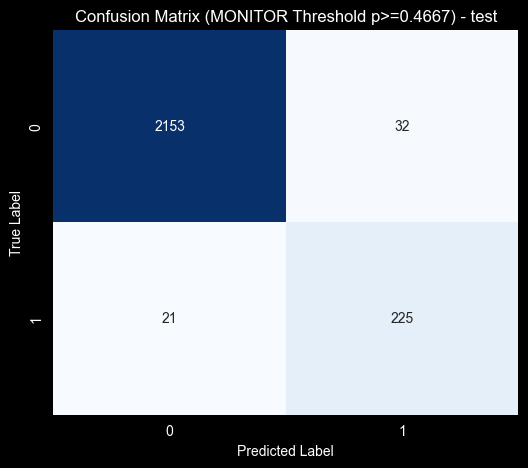

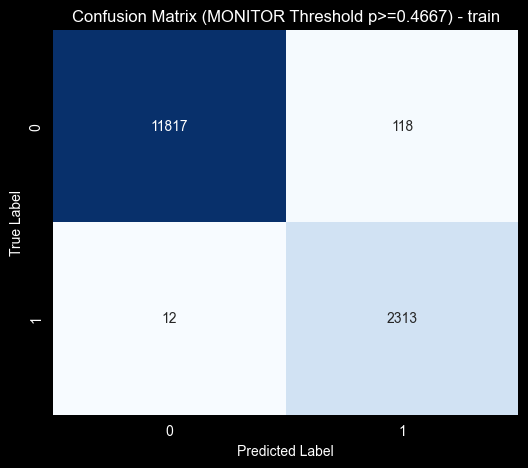

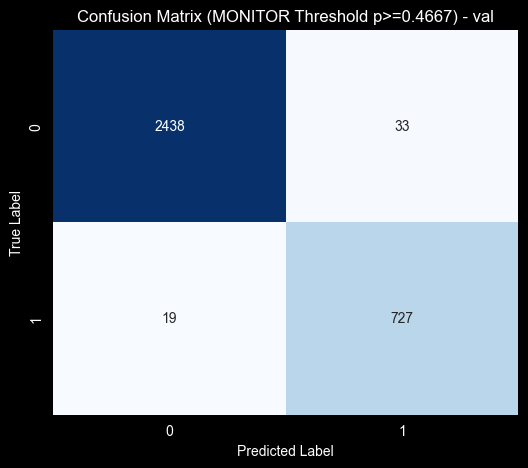


--- Generating Plots for Ensemble ---


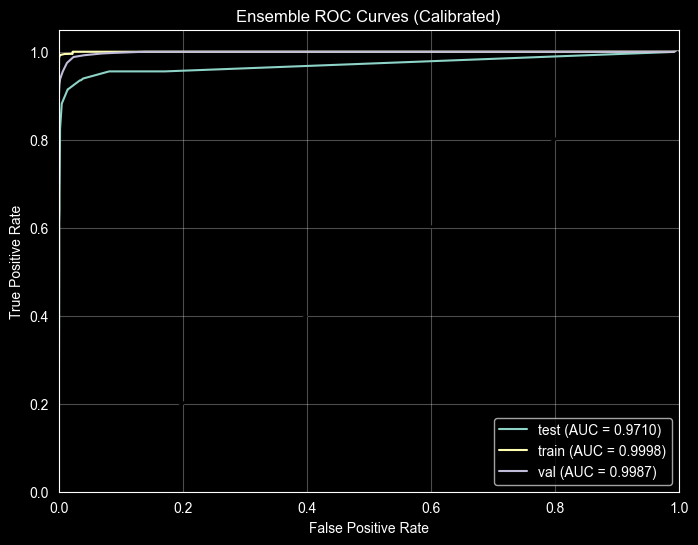

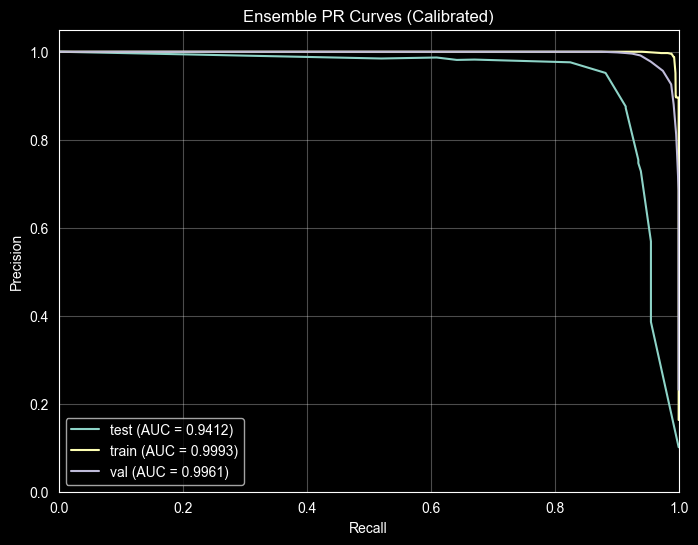

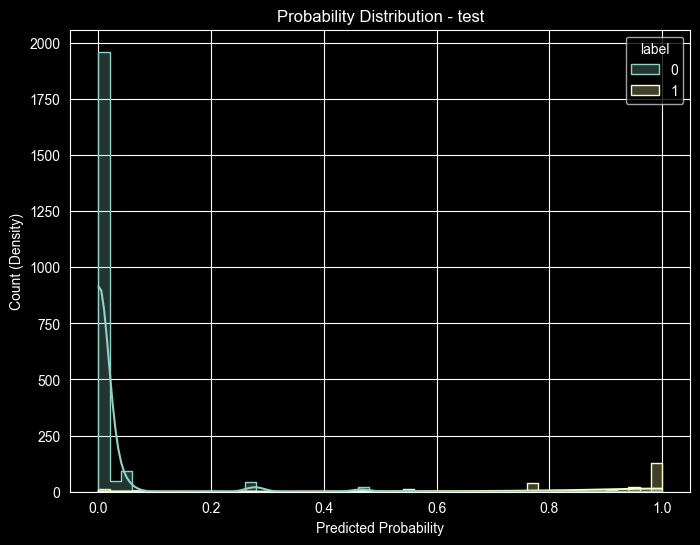

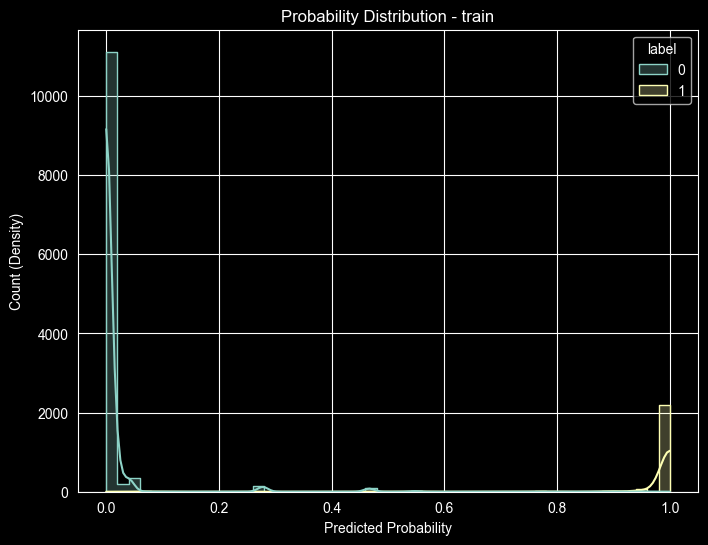

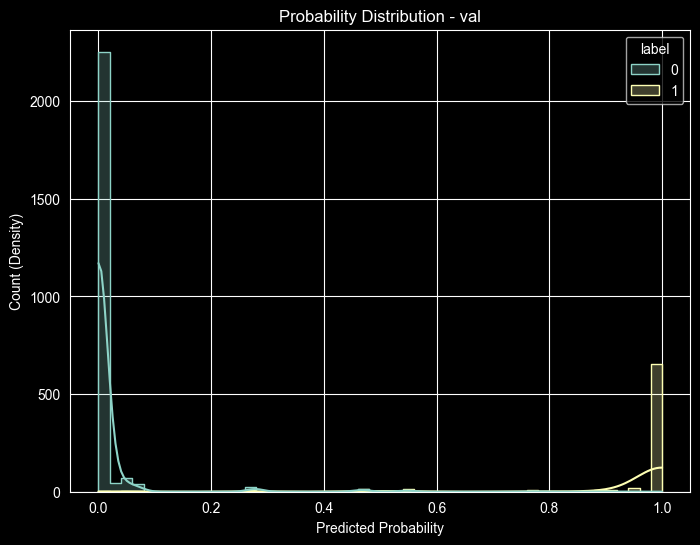


--- Confusion Matrices at Policy Thresholds ---


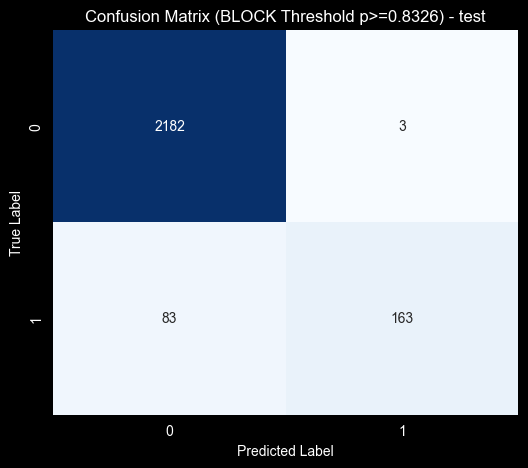

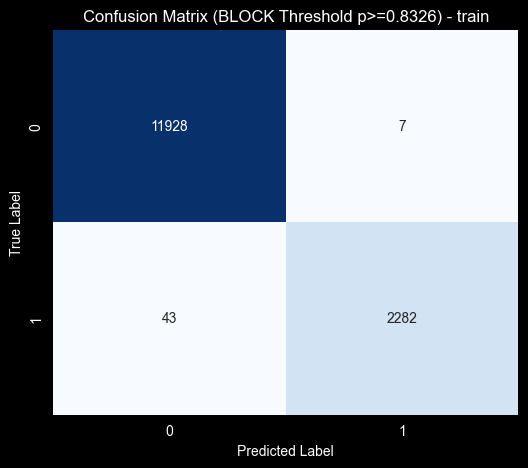

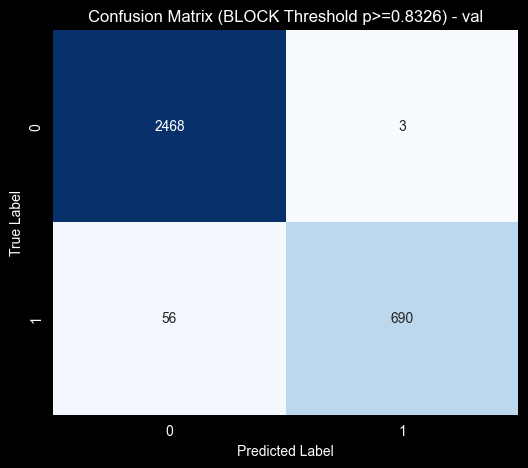

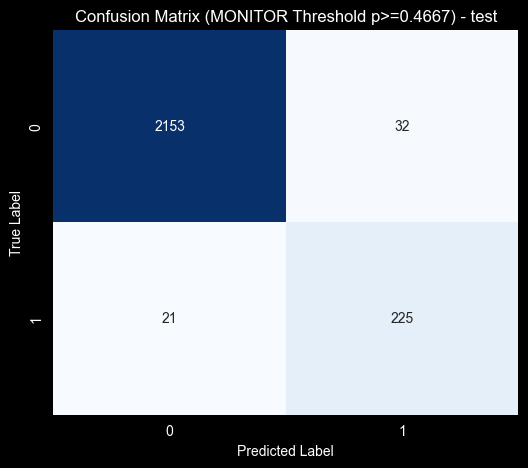

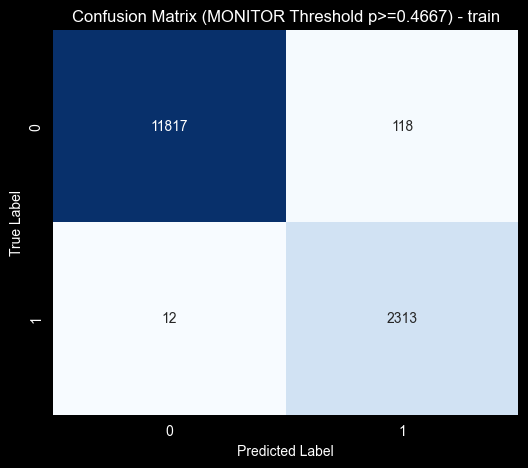

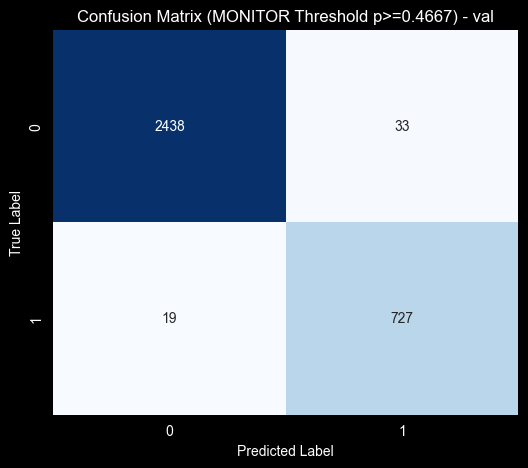

In [6]:
# 4. Visualization
print("\n--- Generating Plots for Ensemble ---")
plot_roc_curves(df_preds, prob_col="p_calib", title="Ensemble ROC Curves (Calibrated)")
plot_pr_curves(df_preds, prob_col="p_calib", title="Ensemble PR Curves (Calibrated)")
plot_probability_distributions(df_preds, prob_col="p_calib")

# REMOVED: plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=0.5)

# NEW: Confusion Matrices for BLOCK and MONITOR thresholds
print("\n--- Confusion Matrices at Policy Thresholds ---")
plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=T_BLOCK, title=f"Confusion Matrix (BLOCK Threshold p>={T_BLOCK:.4f})")
plot_confusion_matrices(df_preds, prob_col="p_calib", threshold=T_MONITOR, title=f"Confusion Matrix (MONITOR Threshold p>={T_MONITOR:.4f})")
